## import and function def

In [2]:
import pandas as pd
from pathlib import Path
import re
import numpy as np
from Bio import Phylo
from collections import Counter

debugging = False

# OGT parsing 
# for ogt text entries, decide on mean ogt and ogt range 
parse_ogt_bounds_text_dict = {
    "moderate to warm": (55, 20),
    "mesophile": (50, 10),
}
def parse_ogt_bounds(value):
    if pd.isna(value):
        return pd.Series([np.nan, np.nan])
    
    key = str(value).strip().lower()
    if key in parse_ogt_bounds_text_dict:
        lower, upper = parse_ogt_bounds_text_dict[key]
        return pd.Series([lower, upper])
    
    parts = re.split(r'[-/]', str(value))
    nums = [float(p.strip()) for p in parts if p.strip()]
    
    if not nums:
        return pd.Series([np.nan, np.nan])
    
    return pd.Series([np.mean([max(nums), min(nums)]), max(nums) - min(nums)])

# number of cys residues parsing
parse_cys_residues_text_dict = {
    "yes": 4,
    "no": 0,
}
def parse_rubredoxin_and_cys_residues(value):
    print(f"value: {value}") if debugging else None
    if pd.isna(value):
        print("value is NaN") if debugging else None
        return np.nan
    
    key = str(value).strip().lower()
    if key in parse_cys_residues_text_dict:
        num = parse_cys_residues_text_dict[key]
        print(f"num: {num}") if debugging else None
        return num
    
    match = re.search(r'(\d+(\.\d+)?)', str(value))
    if match:
        print(f"match: {match.group(1)}") if debugging else None
        return float(match.group(1))
    return np.nan

def build_dendrogram_lines(clade, leaf_x):
    lines = []
    def recurse(c):
        if c.is_terminal():
            return leaf_x[c.name], 0
        child_xy = [recurse(child) for child in c.clades]
        y = max(cy for cx, cy in child_xy) + 1
        x = sum(cx for cx, cy in child_xy) / len(child_xy)
        for cx, cy in child_xy:
            lines.append((cx, -cy, cx, -y))       # negated: leaves at 0, root most negative
        xs = [cx for cx, cy in child_xy]
        lines.append((min(xs), -y, max(xs), -y))
        return x, y
    recurse(clade)
    return lines

def normalize(s):
    return str(s).strip().lower().replace(" ", "_")

# Data Handling

## read file

In [3]:
file_path = Path("../current_working_data/All Homologs.xlsx")  # Replace with your actual file path
print("Found file:", file_path)
sheets = pd.read_excel(file_path, sheet_name=None, engine="openpyxl", header=1)  # Read all sheets into a dictionary
for i, key in enumerate(sheets.keys()):
    print(f"Sheet {i}: {key}, {sheets[key].shape[0]} x {sheets[key].shape[1]}")
# for name, df in sheets.items():
#     print(name, list(df.columns))
print_sample = False
if print_sample:
    print("________________________________________________\nprinting first 5 rows of each sheet...")
    for i, key in enumerate(sheets.keys()):
        print(f"Sheet {i}: {key}")
        print(sheets[key].head())
        print("________________________________________________\n")


Found file: ..\current_working_data\All Homologs.xlsx
Sheet 0: Sheet1, 12 x 12
Sheet 1: Earliest-combine(16), 18 x 11
Sheet 2: Ear-Asgard(37), 41 x 11
Sheet 3: Ear-Bathy(72), 70 x 11
Sheet 4: Mid1-diapherotrites(98), 98 x 11
Sheet 5: Mid1-Mo(292), 297 x 11
Sheet 6: Mid2-Hadesarchaea-between Mo&Mu, 34 x 11
Sheet 7: Mid2-Aenigmarchaeota-after-Hade, 52 x 11
Sheet 8: Mid2-Mu, 110 x 11
Sheet 9: Last-small-pre-evolve, 14 x 11
Sheet 10: Last-bacterial, 185 x 11
Sheet 11: Last-archaeal (237), 0 x 11


## pick data sheet

In [4]:
target_sheet = "Mid2-Hadesarchaea-between Mo&Mu"  # paste in the sheet to look at here
hbs_homolog_df = sheets[target_sheet]

## get OGT values

In [5]:
debugging = False
if debugging: 
    print("sample values at start of pruning:")
    print(hbs_homolog_df["host OGT"])
    print()

# find entries that don't match a clean number/range pattern
pattern = r'^\s*\d+(\.\d+)?(\s*[-/]\s*\d+(\.\d+)?)*\s*$'
mask = hbs_homolog_df["host OGT"].notna() & ~hbs_homolog_df["host OGT"].astype(str).str.match(pattern)
non_numeric_values = hbs_homolog_df.loc[mask, "host OGT"].unique()
print(f"Ensure that the following entries are added to the parse_ogt_bounds text dictionary:\n{non_numeric_values}\n")

# parse host OGT column into lower and upper bounds 
try:
    hbs_homolog_df[["host_ogt_mean", "host_ogt_range"]] = hbs_homolog_df["host OGT"].apply(parse_ogt_bounds)
except Exception as e:
    print("Error. Add non-numeric host OGT values to parse_ogt_bounds text dictionary and rerun.")
print("Successfully parsed host OGT values into lower and upper bounds.")
if debugging:
    print(hbs_homolog_df[["host OGT", "host_ogt_mean", "host_ogt_range"]])

Ensure that the following entries are added to the parse_ogt_bounds text dictionary:
['moderate to warm']

Successfully parsed host OGT values into lower and upper bounds.


## get # cys residues

In [6]:
debugging = False
if debugging: 
    print("sample values at start of pruning:")
    print(hbs_homolog_df["rubredoxin"], hbs_homolog_df["#Cys residue"])
    print()

# parse data input in excel sheet, both rubredoxin and #Cys residue columns, into numeric values
try:
    rub_temp = hbs_homolog_df["rubredoxin"].apply(parse_rubredoxin_and_cys_residues)
    cys_temp = hbs_homolog_df["#Cys residue"].apply(parse_rubredoxin_and_cys_residues)
except Exception as e:
    print("Error. Add non-numeric rubredoxin or #Cys residue values to parse_rubredoxin_and_cys_residues function and rerun.")
# note if data is missing for that line 
hbs_homolog_df["missing_cys_info"] = rub_temp.isna() & cys_temp.isna()
rub_cys_conflict = rub_temp.notna() & cys_temp.notna() & (rub_temp != cys_temp)
# check if there are conflicting values between rubredoxin and #Cys residue columns
print("Entries with conflicting rubredoxin and #Cys residue values:")
print(hbs_homolog_df.loc[rub_cys_conflict, ["rubredoxin", "#Cys residue"]]) if rub_cys_conflict.any() else print("No conflicts found.")
hbs_homolog_df.loc[rub_cys_conflict, ["rubredoxin", "#Cys residue"]]
# combine the two columns into a single column, prioritizing rubredoxin values if present, otherwise using #Cys residue values
hbs_homolog_df["cys_res_in_target_region"] = rub_temp.combine_first(cys_temp).fillna(0)

if debugging:
    print("sample values after parsing:")
    print(hbs_homolog_df["cys_res_in_target_region"])
    print()

Entries with conflicting rubredoxin and #Cys residue values:
No conflicts found.


## get phylogenetic tree

In [8]:
debugging = False
# import and parse tree from itol import
tree = Phylo.read("../current_working_data/Hbs_homolog_tree.txt", "phyloxml")
leaf_names = [term.name for term in tree.get_terminals()]
ids = set(leaf_names)
print(ids) if debugging else None

# check for duplicates in imported tree 
normalized_leaf_names = [normalize(name) for name in leaf_names]
leaf_name_counts = Counter(normalized_leaf_names)
duplicate_tree_names = {name for name, count in leaf_name_counts.items() if count > 1}

if duplicate_tree_names:
    print(f"Dropping {len(duplicate_tree_names)} duplicate leaf name(s) from tree:")
    for term in tree.get_terminals():
        if normalize(term.name) in duplicate_tree_names:
            print(f"  {term.name}")
else:
    print("No duplicate leaf names found in tree.")

for term in list(tree.get_terminals()):  # list() first — prune() modifies the tree as you go
    if normalize(term.name) in duplicate_tree_names:
        tree.prune(term)

# check for duplicates in parsed spreadsheet 
name_col = "name from tree"
id_col = "sequence ID"
hbs_homolog_df["_norm_name"] = hbs_homolog_df[name_col].apply(normalize)

name_counts = hbs_homolog_df["_norm_name"].value_counts()
duplicate_names = name_counts[name_counts > 1].index

if len(duplicate_names) > 0:
    print(f"Dropping {len(duplicate_names)} name(s) appearing in multiple rows in Hbs homolog sheet:")
    for name in duplicate_names:
        rows = hbs_homolog_df.loc[hbs_homolog_df["_norm_name"] == name, [id_col, name_col]]
        print(f"\n  '{name}':")
        print(rows.to_string(index=False))
else:
    print("No duplicate names found in Hbs homolog sheet.")

hbs_homolog_df = hbs_homolog_df[~hbs_homolog_df["_norm_name"].isin(duplicate_names)].copy()

# skip all leaves without sequence ID in Hbs homolog df 
sequence_ids = set(hbs_homolog_df["name from tree"])
print(sequence_ids) if debugging else None

for term in list(tree.get_terminals()):
    if term.name not in sequence_ids:
        tree.prune(term)

remaining_ids = [leaf.name for leaf in tree.get_terminals()]
print(f"{len(remaining_ids)} sequence IDs remaining after pruning.")
print(remaining_ids) if debugging else None

tree.ladderize()

leaves = tree.get_terminals()
leaf_order = [leaf.name for leaf in leaves]
leaf_x = {name: i for i, name in enumerate(leaf_order)}

Dropping 83 duplicate leaf name(s) from tree:
  Hadesarchaea archaeon DG-33
  Hadesarchaea archaeon 8_1_Jan_SF_Bin79
  candidate divison MSBL1 archaeon SCGC-AAA259J03
  candidate division MSBL1 archaeon SCGC-AAA259J03 SCGC-AAA259J03
  Unclassified archaeon JZ bin_30
  Candidatus Verstraetearchaeota archaeon Bin S2
  Candidatus Culexarchaeum yellowstonense YNP-LCB-24-027
  Candidatus Culexarchaeum nevadense GBS-70-058
  Candidatus Aenigmarchaeota archaeon B55_G9
  Candidatus Verstraetearchaeota archaeon AUK031
  Candidatus Bathyarchaeota archaeon B1_G13
  Candidatus Bathyarchaeota archaeon AUK245
  Candidatus Bathyarchaeota archaeon HyVt-137
  Candidatus Bathyarchaeota archaeon AUK158
  Candidatus Bathyarchaeota archaeon B24-2 B24-2
  Candidatus Korarchaeota archaeon HyVt-138
  Candidatus Korarchaeota archaeon B41_G2
  Candidatus Korarchaeota archaeon B8_G17
  Archaeoglobales archaeon B10_G2
  Archaeoglobaceae archaeon UWMA-0193
  Archaeoglobales archaeon B4_G15
  Archaeoglobales archae

# Plot data

## import

In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

plt.rcParams["font.weight"] = "bold"  # Bolds general text (titles, etc.)
plt.rcParams["axes.labelweight"] = "bold"  # Bolds x and y axis labels

## set plot title, legend, colors

In [10]:
plot_title = f"Host OGT vs # cys residues in __ domain\n{target_sheet}"
plot_x_label = "Phylogenetic tree of Hbs homologs"
plot_y_label = "Host optimal growth temp (C)"
fig_size = [10, 6]

## plot

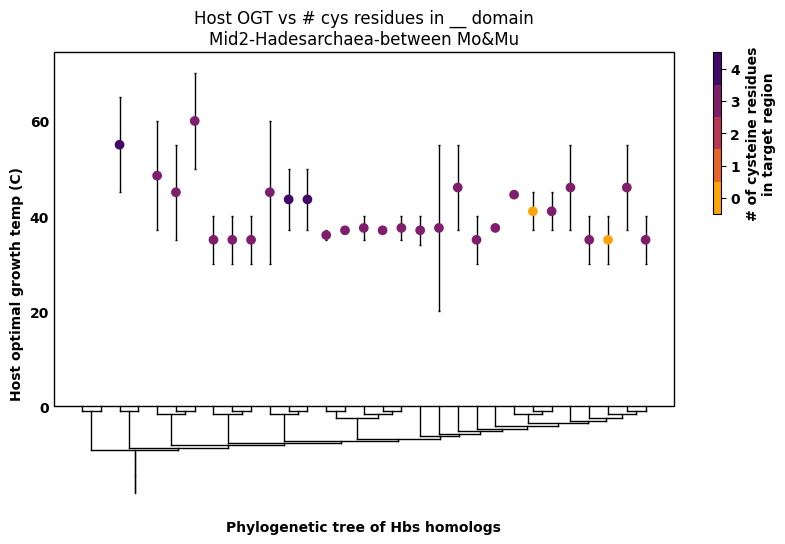

In [82]:
# rebuild tree, ignoring branch length 
lines = build_dendrogram_lines(tree.root, leaf_x)
height_compression = .8
lines = [(x0, -(abs(y0) ** height_compression), x1, -(abs(y1) ** height_compression)) for x0, y0, x1, y1 in lines]
print(leaf_x) if debugging else None 

print(hbs_homolog_df["cys_res_in_target_region"]) if debugging else None

# plot dendrogram 
fig, ax = plt.subplots(figsize=(fig_size))
for x0, y0, x1, y1 in lines:
    ax.plot([x0, x1], [y0, y1], color="black", lw=1)

# get optimal growth temps and range for y axis and error 
y_lookup = hbs_homolog_df.set_index("name from tree")["host_ogt_mean"]
ogt_lookup = hbs_homolog_df.set_index("name from tree")["host_ogt_range"].astype(float)
ys = [y_lookup[name] for name in leaf_order]
y_errors = [ogt_lookup[name] / 2 for name in leaf_order]

# get num cys residues for color 
cys_lookup = hbs_homolog_df.set_index("name from tree")["cys_res_in_target_region"]
xs = [leaf_x[name] for name in leaf_order]
cys_values = [cys_lookup[name] for name in leaf_order]

# make colormap
cys_cmap = mcolors.ListedColormap(
    plt.get_cmap("inferno_r")(np.linspace(0.2, 0.8, 5))
)
cys_norm = mcolors.BoundaryNorm(np.arange(-0.5, 5.5, 1), cys_cmap.N)

# put error bars on (first so that points are on top)
ax.errorbar(
    xs,
    ys,
    yerr=y_errors,
    fmt="none",
    ecolor="black",
    elinewidth=1,
    capsize=1,
    zorder=2,
)

# plot scatters 
scatter = ax.scatter(
    xs,
    ys,
    c=cys_values,
    cmap=cys_cmap,
    norm=cys_norm,
    zorder=3,
)

# make colorbar legend 
cbar = fig.colorbar(
    scatter,
    ax=ax,
    ticks=range(5),
    boundaries=np.arange(-0.5, 5.5, 1),
    spacing="uniform",
    shrink=0.35,
    anchor=(0, 1),
)
cbar.ax.minorticks_off()
cbar.set_label("# of cysteine residues\nin target region")

from matplotlib.ticker import FuncFormatter

ax.set_xticks([])
ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

# remove y axis ticks, and labels below 0 
ax.tick_params(axis="y", which="both", length=0)
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: "" if value < 0 else f"{value:g}")
)

# remove box around whole plot
for spine in ax.spines.values():
    spine.set_visible(False)
x_min, x_max = ax.get_xlim()
_, y_max = ax.get_ylim()

# draw box around main plot so that dendrogram looks good
ax.add_patch(
    mpatches.Rectangle(
        (x_min, 0),
        x_max - x_min,
        y_max,
        fill=False,
        edgecolor="black",
        linewidth=1,
        clip_on=False,
    )
)

plt.title(plot_title)
plt.xlabel(plot_x_label)
plt.ylabel(plot_y_label)
plt.show()